# Milestone 2: Facial Recognition Model Development & Evaluation
**System:** Intelligent Shop Security

## Objective
Develop a facial recognition model that can efficiently detect and recognize faces, and evaluate its performance using key metrics.

---

We selected **FaceNet** (via the **DeepFace** framework).

| Aspect | Detail |
|--------|--------|
| Architecture | Inception-ResNet-v1 (FaceNet) |
| Embedding Size | 128-D |
| Input Size | 160 × 160 × 3 |
| Parameters | ~22.8 M |
| Similarity Metric | Cosine Distance |
| Framework | DeepFace wrapper |

The model is **pre-trained** on a large-scale face dataset. We leverage **transfer learning** by using the frozen weights directly — no fine-tuning of the CNN backbone is needed. The pre-trained FaceNet model already produces highly discriminative 128-D embeddings suitable for our security application.


In [1]:
# 1. Imports & Model Loading
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2, os, random, time, warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)
from scipy.spatial.distance import cosine
from deepface import DeepFace

print('Loading FaceNet Model via DeepFace (same as core_logic.py)...')
built = DeepFace.build_model('Facenet')
embedding_model = built.model if hasattr(built, 'model') else built
print('Model loaded successfully!')
print(f'   Input shape : {embedding_model.input_shape}')
print(f'   Output shape: {embedding_model.output_shape}')
print(f'   Total params: {embedding_model.count_params():,}')


Loading FaceNet Model via DeepFace (same as core_logic.py)...
Model loaded successfully!
   Input shape : (None, 160, 160, 3)
   Output shape: (None, 128)
   Total params: 22,808,144


### Model Architecture Summary
Below is a high-level summary of the FaceNet (Inception-ResNet-v1) model used in our system.

In [2]:
embedding_model.summary()


Model: "inception_resnet_v1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 160, 160, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv2d_1a_3x3 (Conv2D)         (None, 79, 79, 32)   864         ['input_1[0][0]']                
                                                                                                  
 Conv2d_1a_3x3_BatchNorm (Batch  (None, 79, 79, 32)  96          ['Conv2d_1a_3x3[0][0]']          
 Normalization)                                                                                   
                                                                                

## Loading the Processed Dataset
The preprocessed LFW dataset was saved by Milestone 1 as an `.npz` file containing:
- `images` – face images (N, 125, 94, 3) float32 [0-1]
- `labels` – integer class labels
- `target_names` – identity names


In [ ]:
# 2. Load Processed Dataset
DATASET_PATH = '../data/processed_dataset/lfw_dataset.npz'

print(f'Loading dataset from: {DATASET_PATH}')
data = np.load(DATASET_PATH, allow_pickle=True)

images       = data['images']
labels       = data['labels']
target_names = data['target_names']

print(f'Dataset loaded successfully!')
print(f'   Images      : {images.shape}  dtype={images.dtype}')
print(f'   Labels      : {labels.shape}  dtype={labels.dtype}')
print(f'   Identities  : {len(target_names)}')
print(f'   Pixel range  : [{images.min():.2f}, {images.max():.2f}]')


📂 Loading dataset from: ../data/processed_dataset/lfw_dataset.npz
✅ Dataset loaded successfully!
   Images      : (2936, 125, 94, 3)  dtype=float32
   Labels      : (2936,)  dtype=int64
   Identities  : 59
   Pixel range  : [0.00, 1.00]


## Preprocessing & Embedding Generation
We preprocess each image exactly as `core_logic.py` does:
1. Resize to **160 × 160** (FaceNet input size)
2. Normalize pixels to **[0, 1]**
3. Generate **128-D embedding** via `model.predict()`


In [ ]:
# 3. Generate Embeddings:
TARGET_SIZE = (160, 160)

def preprocess_face(face_img):
    """Resize + normalize for FaceNet (mirrors core_logic.py)."""
    face_resized = cv2.resize(face_img, TARGET_SIZE)
    return np.expand_dims(face_resized, axis=0).astype(np.float32) / 255.0

def get_embedding(img):
    """Generate 128-D embedding for a single image."""
    preprocessed = preprocess_face(img)
    return embedding_model.predict(preprocessed, verbose=0)[0]

print('Generating embeddings for all images...')
start_time = time.time()

embeddings = []
for i, img in enumerate(images):
    # images are already float32 [0-1] from M1, convert to [0-255] uint8 for resize
    img_uint8 = (img * 255).astype(np.uint8) if img.max() <= 1.0 else img.astype(np.uint8)
    emb = get_embedding(img_uint8)
    embeddings.append(emb)
    if (i + 1) % 500 == 0:
        print(f'   Processed {i+1}/{len(images)} images...')

embeddings = np.array(embeddings)
elapsed = time.time() - start_time

print(f'All embeddings generated!')
print(f'   Embeddings shape: {embeddings.shape}')
print(f'   Total time: {elapsed:.1f}s')
print(f'   Avg per image: {elapsed/len(images)*1000:.1f}ms')


⏳ Generating embeddings for all images...
   Processed 500/2936 images...
   Processed 1000/2936 images...
   Processed 1500/2936 images...
   Processed 2000/2936 images...
   Processed 2500/2936 images...
✅ All embeddings generated!
   Embeddings shape: (2936, 128)
   Total time: 218.2s
   Avg per image: 74.3ms


## Evaluation Methodology

We evaluate both **verification** (same person?) and **identification** performance.

Pairs are generated from the embedded dataset:
- **Positive pairs** – two images of the **same** person (label = 1)
- **Negative pairs** – two images of **different** people (label = 0)

### Key Metrics
| Metric | Formula |
|--------|---------|
| Accuracy | $(TP+TN) / (TP+TN+FP+FN)$ |
| Precision | $TP / (TP+FP)$ |
| Recall | $TP / (TP+FN)$ |
| F1-score | $2 \times \frac{Precision \times Recall}{Precision + Recall}$ |
| FAR (False Acceptance Rate) | $FP / (FP+TN)$ |
| FRR (False Rejection Rate) | $FN / (FN+TP)$ |


In [5]:
# 4. Generate Evaluation Pairs
NUM_POSITIVE = 500
NUM_NEGATIVE = 500

random.seed(42)
np.random.seed(42)

# Group indices by label
label_to_indices = {}
for idx, lbl in enumerate(labels):
    label_to_indices.setdefault(int(lbl), []).append(idx)

# Classes with >= 2 images (for positive pairs)
valid_classes = [c for c, idxs in label_to_indices.items() if len(idxs) >= 2]
all_classes   = list(label_to_indices.keys())

print(f'Total classes: {len(all_classes)}')
print(f'Classes with ≥2 images (for positive pairs): {len(valid_classes)}')

pairs = []
y_true = []

# Positive pairs
for _ in range(NUM_POSITIVE):
    cls = random.choice(valid_classes)
    i1, i2 = random.sample(label_to_indices[cls], 2)
    pairs.append((embeddings[i1], embeddings[i2]))
    y_true.append(1)

# Negative pairs
for _ in range(NUM_NEGATIVE):
    c1, c2 = random.sample(all_classes, 2)
    i1 = random.choice(label_to_indices[c1])
    i2 = random.choice(label_to_indices[c2])
    pairs.append((embeddings[i1], embeddings[i2]))
    y_true.append(0)

y_true = np.array(y_true)
print(f'\nGenerated {len(pairs)} pairs ({NUM_POSITIVE} positive, {NUM_NEGATIVE} negative)')


Total classes: 59
Classes with ≥2 images (for positive pairs): 59

Generated 1000 pairs (500 positive, 500 negative)


## Task 4 – Model Optimization: Threshold Tuning
We sweep cosine-distance thresholds to find the optimal operating point that maximises F1 while keeping FAR low (critical for security).


In [ ]:
# 5. Compute Distances & Sweep Thresholds
distances = np.array([cosine(e1, e2) for e1, e2 in pairs])

thresholds = np.arange(0.05, 0.80, 0.01)
results = []

for thr in thresholds:
    y_pred = (distances < thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    acc  = (tp + tn) / (tp + tn + fp + fn)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2*prec*rec / (prec + rec) if (prec + rec) > 0 else 0
    far  = fp / (fp + tn) if (fp + tn) > 0 else 0
    frr  = fn / (fn + tp) if (fn + tp) > 0 else 0
    results.append({'threshold': thr, 'accuracy': acc, 'precision': prec,
                    'recall': rec, 'f1': f1, 'far': far, 'frr': frr,
                    'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn})

# Find best F1
best = max(results, key=lambda r: r['f1'])
BEST_THR = round(best['threshold'], 2)
print(f'Best threshold (max F1): {BEST_THR}')
print(f'   F1={best["f1"]:.4f}  Acc={best["accuracy"]:.4f}  FAR={best["far"]:.4f}  FRR={best["frr"]:.4f}')


🏆 Best threshold (max F1): 0.62
   F1=0.9579  Acc=0.9580  FAR=0.0400  FRR=0.0440


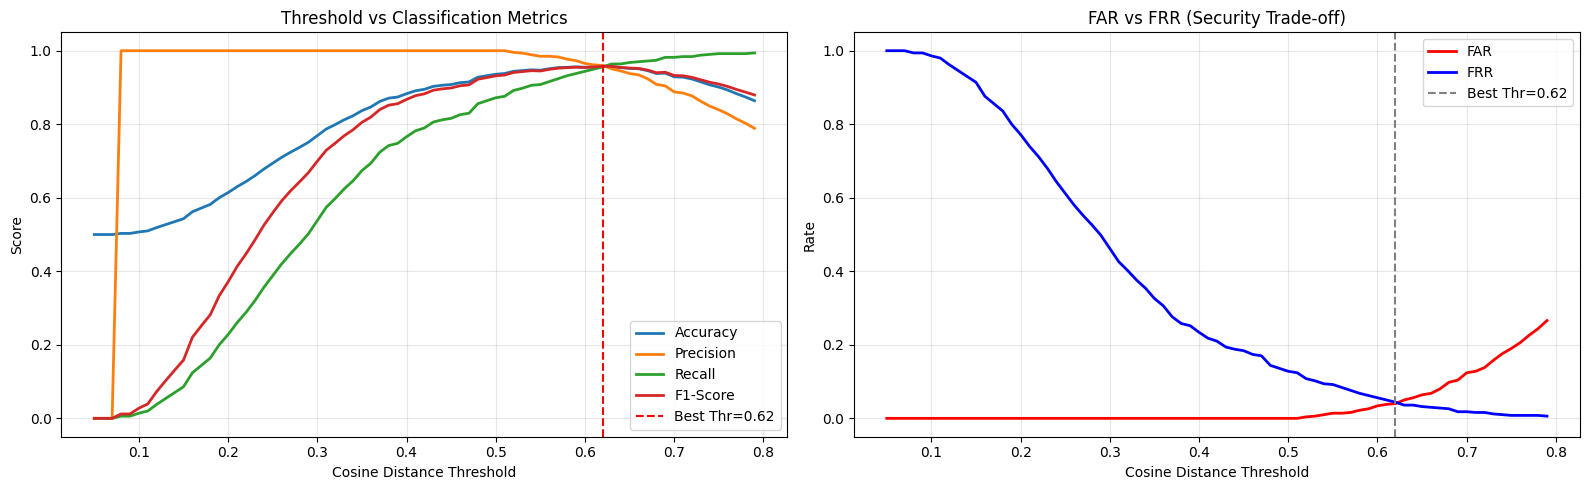

In [7]:
# 6. Visualize Threshold vs Metrics
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

thrs = [r['threshold'] for r in results]

ax1 = axes[0]
ax1.plot(thrs, [r['accuracy']  for r in results], label='Accuracy',  linewidth=2)
ax1.plot(thrs, [r['precision'] for r in results], label='Precision', linewidth=2)
ax1.plot(thrs, [r['recall']    for r in results], label='Recall',    linewidth=2)
ax1.plot(thrs, [r['f1']        for r in results], label='F1-Score',  linewidth=2)
ax1.axvline(BEST_THR, color='red', linestyle='--', label=f'Best Thr={BEST_THR}')
ax1.set_xlabel('Cosine Distance Threshold')
ax1.set_ylabel('Score')
ax1.set_title('Threshold vs Classification Metrics')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(thrs, [r['far'] for r in results], label='FAR', linewidth=2, color='red')
ax2.plot(thrs, [r['frr'] for r in results], label='FRR', linewidth=2, color='blue')
ax2.axvline(BEST_THR, color='gray', linestyle='--', label=f'Best Thr={BEST_THR}')
ax2.set_xlabel('Cosine Distance Threshold')
ax2.set_ylabel('Rate')
ax2.set_title('FAR vs FRR (Security Trade-off)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Task 3 – Model Evaluation Results
Final metrics at the optimal threshold:


In [8]:
# 7. Final Evaluation at Best Threshold
y_pred = (distances < BEST_THR).astype(int)

acc       = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall    = recall_score(y_true, y_pred)
f1        = f1_score(y_true, y_pred)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
far = fp / (fp + tn) if (fp + tn) > 0 else 0
frr = fn / (fn + tp) if (fn + tp) > 0 else 0

print('=' * 50)
print('MODEL EVALUATION RESULTS')
print('=' * 50)
print(f'Threshold:  {BEST_THR}')
print(f'Accuracy:   {acc * 100:.2f}%')
print(f'Precision:  {precision * 100:.2f}%')
print(f'Recall:     {recall * 100:.2f}%')
print(f'F1-Score:   {f1:.4f}')
print('-' * 50)
print(f'False Acceptance Rate (FAR): {far * 100:.2f}%')
print(f'False Rejection Rate (FRR):  {frr * 100:.2f}%')
print('-' * 50)
print(f'TP={tp}  TN={tn}  FP={fp}  FN={fn}')
print('=' * 50)


MODEL EVALUATION RESULTS
Threshold:  0.62
Accuracy:   95.80%
Precision:  95.98%
Recall:     95.60%
F1-Score:   0.9579
--------------------------------------------------
False Acceptance Rate (FAR): 4.00%
False Rejection Rate (FRR):  4.40%
--------------------------------------------------
TP=478  TN=480  FP=20  FN=22


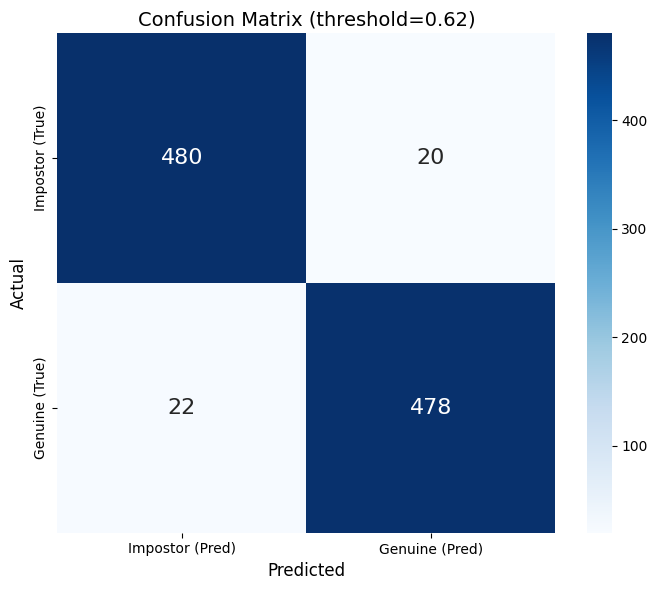

In [9]:
# 8. Confusion Matrix Visualization
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Impostor (Pred)', 'Genuine (Pred)'],
            yticklabels=['Impostor (True)', 'Genuine (True)'],
            annot_kws={'size': 16}, ax=ax)
ax.set_title(f'Confusion Matrix (threshold={BEST_THR})', fontsize=14)
ax.set_ylabel('Actual', fontsize=12)
ax.set_xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()


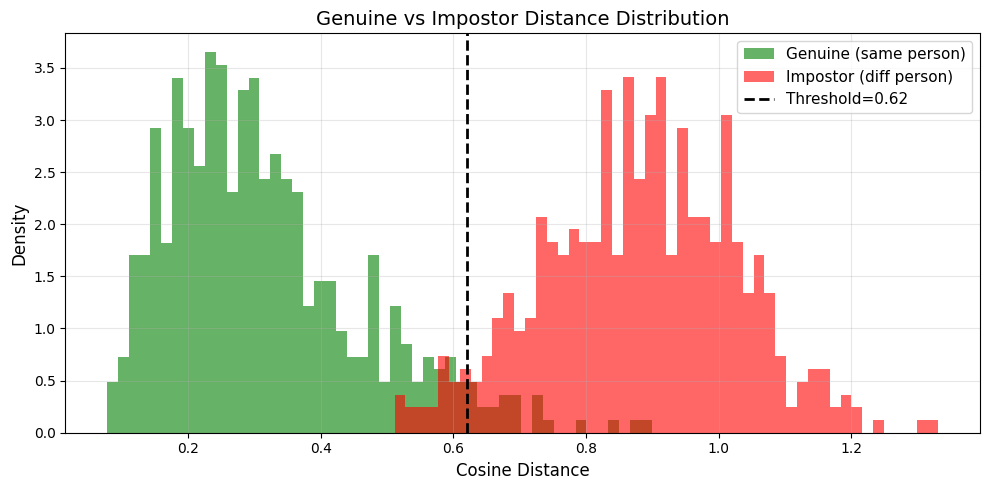

Genuine  distances: mean=0.3163, std=0.1485
Impostor distances: mean=0.8813, std=0.1448


In [10]:
# 9. Genuine vs Impostor Distance Distribution
genuine_distances  = distances[y_true == 1]
impostor_distances = distances[y_true == 0]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(genuine_distances,  bins=50, alpha=0.6, label='Genuine (same person)',  color='green', density=True)
ax.hist(impostor_distances, bins=50, alpha=0.6, label='Impostor (diff person)', color='red',   density=True)
ax.axvline(BEST_THR, color='black', linestyle='--', linewidth=2, label=f'Threshold={BEST_THR}')
ax.set_xlabel('Cosine Distance', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Genuine vs Impostor Distance Distribution', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Genuine  distances: mean={genuine_distances.mean():.4f}, std={genuine_distances.std():.4f}')
print(f'Impostor distances: mean={impostor_distances.mean():.4f}, std={impostor_distances.std():.4f}')


## Task 4 – Inference Speed Optimization
We measure the real-time inference speed to ensure the model meets the requirements of our live camera system.


In [11]:
# 10. Inference Speed Benchmark
NUM_BENCH = 100
sample_img = (images[0] * 255).astype(np.uint8) if images[0].max() <= 1.0 else images[0].astype(np.uint8)

# Warm-up
for _ in range(5):
    _ = get_embedding(sample_img)

times = []
for _ in range(NUM_BENCH):
    t0 = time.time()
    _ = get_embedding(sample_img)
    times.append(time.time() - t0)

times = np.array(times) * 1000 
print(f'Inference Speed Benchmark ({NUM_BENCH} runs):')
print(f'   Mean: {times.mean():.2f} ms/image')
print(f'   Std:  {times.std():.2f} ms')
print(f'   Min:  {times.min():.2f} ms')
print(f'   Max:  {times.max():.2f} ms')
print(f'   Throughput: ~{1000/times.mean():.1f} faces/sec')


Inference Speed Benchmark (100 runs):
   Mean: 77.62 ms/image
   Std:  5.65 ms
   Min:  68.25 ms
   Max:  101.52 ms
   Throughput: ~12.9 faces/sec
